> **Traçabilité (fusion Codes_finaux) :** notebook présent uniquement dans `Codes prof/MNIST_4_VGG16_Keras.ipynb` (pas d'équivalent Colab), copié tel quel.

---
# VGG16 : `MNIST` (avec `Keras`)
---

## Packages

In [1]:
import numpy as np

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

import keras
from keras import callbacks, layers, models
from keras.applications import VGG16
from keras.applications.vgg16 import preprocess_input
from keras.datasets import mnist

import tensorflow as tf

---
## 1. Données
---

### 1.1. Importation

In [2]:
(X_train_valid, y_train_valid), (X_test, y_test) = mnist.load_data()

X_train, X_valid, y_train, y_valid = train_test_split(X_train_valid, y_train_valid, test_size=1/5)

print('Dimensions de X_train :', X_train.shape)
print('Dimensions de X_valid :', X_valid.shape)
print('Dimensions de X_test  :', X_test.shape)

print('Dimensions de y_train :', y_train.shape)
print('Dimensions de y_valid :', y_valid.shape)
print('Dimensions de y_test  :', y_test.shape)

Dimensions de X_train : (48000, 28, 28)
Dimensions de X_valid : (12000, 28, 28)
Dimensions de X_test  : (10000, 28, 28)
Dimensions de y_train : (48000,)
Dimensions de y_valid : (12000,)
Dimensions de y_test  : (10000,)


### 1.2. Graphiques

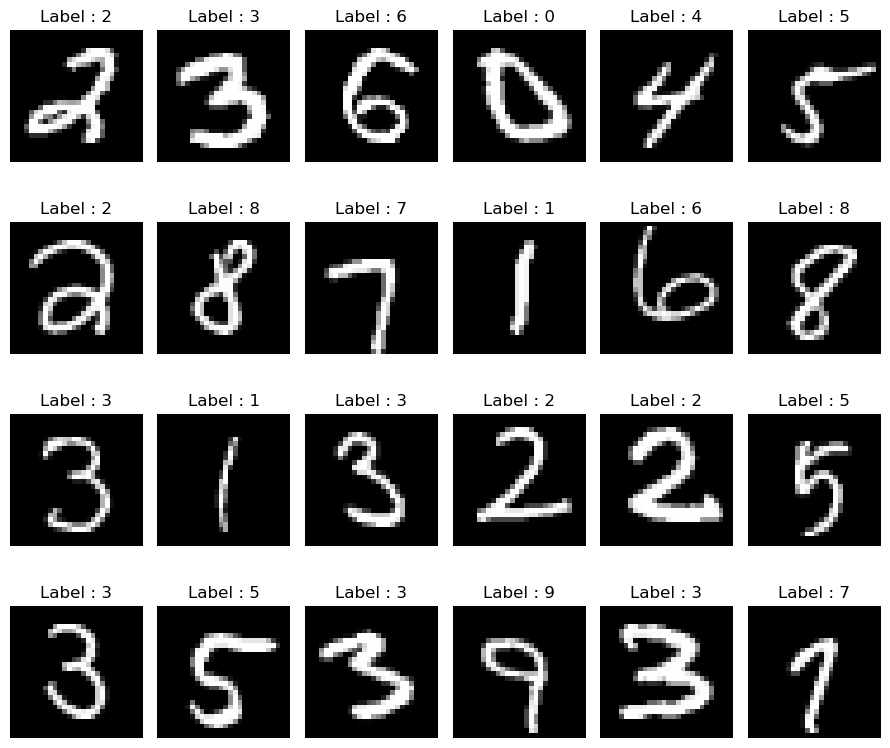

In [3]:
n_row = 4
n_col = 6
n = n_row * n_col

images = X_train[:n]
labels = y_train[:n]

fig, axes = plt.subplots(n_row, n_col, figsize=(1.5 * n_col, 2 * n_row))
for i in range(n):
    ax = axes[i//n_col, i%n_col]
    ax.imshow(images[i], cmap='gray')
    ax.set_title(f'Label : {labels[i]}')
    ax.axis('off')
plt.tight_layout()
plt.show()

### 1.3. Redimensionnement

On met les images au format $48\times 48$ pixels, sur 3 niveaux de couleur (RGB) :

In [4]:
dim_inputs_new = 48
n_colors       = 3

def resize_images(images):
  images = images.astype('float32')
  images = np.expand_dims(images, axis=-1)
  images = np.repeat(images, n_colors, axis=-1)
  images = tf.image.resize(images, [dim_inputs_new, dim_inputs_new])
  return images

X_train = resize_images(X_train)
X_valid = resize_images(X_valid)
X_test  = resize_images(X_test)

print('Dimensions de X_train :', X_train.shape)
print('Dimensions de X_valid :', X_valid.shape)
print('Dimensions de X_test  :', X_test.shape)

Dimensions de X_train : (48000, 48, 48, 3)
Dimensions de X_valid : (12000, 48, 48, 3)
Dimensions de X_test  : (10000, 48, 48, 3)


### 1.4. Normalisation

Pour utiliser VGG16, on normalise les données en retirant les moyennes de chaque niveau de couleur sur le jeu de données imageNet (challenge) :

In [5]:
X_train_norm = preprocess_input(X_train)
X_valid_norm = preprocess_input(X_valid)
X_test_norm  = preprocess_input(X_test)

---
## 2. VGG16
---

### 2.1. Architecture

In [6]:
dim_outputs = 10

n_units_hl = 256
dropout_hl = 0.2

model = keras.models.Sequential(name='CNN')

activation_input  = 'relu'
activation_output = 'softmax'

optimizer = 'adam'
loss      = 'categorical_crossentropy'
metrics   = ['accuracy']

input_tensor = layers.Input(shape=(dim_inputs_new, dim_inputs_new, n_colors))

model_prior = VGG16(weights='imagenet',
                    include_top=False,
                    input_tensor=input_tensor)

x = layers.Flatten()(model_prior.output)
x = layers.Dense(units=n_units_hl, activation=activation_input)(x)
x = layers.Dropout(rate=dropout_hl)(x)
output = layers.Dense(units=dim_outputs, activation=activation_output)(x)

model = models.Model(inputs=input_tensor, outputs=output)

for layer in model_prior.layers:
    layer.trainable = False

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 48, 48, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 48, 48, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 48, 48, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 24, 24, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 24, 24, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 12, 12, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 12, 12, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 12, 12, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 6, 6, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 6, 6, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 6, 6, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 3, 3, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 3, 3, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 3, 3, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 3, 3, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 1, 1, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,848,586 (56.64 MB)

 Trainable params: 133,898 (523.04 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

### 2.2. Optimiseur

In [7]:
model.compile(optimizer = 'adam',
              loss      = 'sparse_categorical_crossentropy',
              metrics   = ['accuracy'])

callback = callbacks.EarlyStopping(monitor              = 'val_loss',
                                   mode                 = 'min',
                                   patience             = 5,
                                   restore_best_weights = True)

### 2.3. Entraînement

In [8]:
hist = model.fit(X_train_norm,
                 y_train,
                 batch_size      = 300,
                 epochs          = 50,
                 validation_data = (X_valid_norm, y_valid),
                 callbacks       = [callback],
                 verbose         = 1)

Epoch 1/50
160/160 ━━━━━━━━━━━━━━━━━━━━ 103s 644ms/step - accuracy: 0.6017 - loss: 3.2483 - val_accuracy: 0.9144 - val_loss: 0.2890
Epoch 2/50
160/160 ━━━━━━━━━━━━━━━━━━━━ 107s 672ms/step - accuracy: 0.8975 - loss: 0.3291 - val_accuracy: 0.9332 - val_loss: 0.2217
Epoch 3/50
160/160 ━━━━━━━━━━━━━━━━━━━━ 112s 700ms/step - accuracy: 0.9252 - loss: 0.2361 - val_accuracy: 0.9418 - val_loss: 0.1867
Epoch 4/50
160/160 ━━━━━━━━━━━━━━━━━━━━ 113s 708ms/step - accuracy: 0.9390 - loss: 0.1914 - val_accuracy: 0.9457 - val_loss: 0.1742
Epoch 5/50
160/160 ━━━━━━━━━━━━━━━━━━━━ 146s 916ms/step - accuracy: 0.9475 - loss: 0.1605 - val_accuracy: 0.9503 - val_loss: 0.1584
Epoch 6/50
160/160 ━━━━━━━━━━━━━━━━━━━━ 735s 5s/step - accuracy: 0.9545 - loss: 0.1419 - val_accuracy: 0.9538 - val_loss: 0.1506
Epoch 7/50
160/160 ━━━━━━━━━━━━━━━━━━━━ 531s 3s/step - accuracy: 0.9571 - loss: 0.1331 - val_accuracy: 0.9573 - val_loss: 0.1412
Epoch 8/50
160/160 ━━━━━━━━━━━━━━━━━━━━ 108s 678ms/step - accuracy: 0.9619 - loss:

### 2.4. Prévisions

In [9]:
y_test_pred = model.predict(X_test_norm)
y_test_pred[0:5]

313/313 ━━━━━━━━━━━━━━━━━━━━ 23s 73ms/step


array([[5.4638512e-11, 4.7334925e-05, 1.0412487e-06, 1.7105819e-12,
        3.4188550e-09, 3.8074526e-09, 3.0534478e-11, 9.9995160e-01,
        1.4492750e-13, 6.5636446e-10],
       [4.2978368e-09, 5.5723683e-09, 9.9998075e-01, 8.7950930e-08,
        4.8364659e-09, 1.8585664e-05, 1.2561078e-07, 2.5157388e-07,
        8.1186419e-13, 1.9748538e-07],
       [1.0821998e-13, 1.0000000e+00, 5.1892683e-12, 3.7332646e-16,
        3.3033430e-11, 2.5264923e-12, 9.7535235e-10, 3.6097642e-10,
        3.4692631e-15, 4.2083231e-13],
       [9.9999976e-01, 1.1139321e-12, 3.1065089e-10, 6.5771498e-12,
        1.6653184e-09, 3.1315217e-08, 9.7173960e-08, 4.7697572e-08,
        7.5293869e-08, 1.0400230e-09],
       [3.6581201e-07, 3.5055780e-07, 1.8618099e-08, 3.5236255e-08,
        9.9995965e-01, 7.5416324e-06, 2.1318852e-05, 4.5686397e-07,
        2.4128573e-07, 1.0155743e-05]], dtype=float32)

In [10]:
y_test_pred_classes = np.argmax(y_test_pred, axis=1)
y_test_pred_classes[0:5]

array([7, 2, 1, 0, 4])

In [11]:
score_test = model.evaluate(X_test_norm, y_test, verbose=0)
print(f'Entropie test   : {score_test[0]:4.4f}')
print(f'Exactitude test : {score_test[1]:4.4f}')

Entropie test   : 0.1277
Exactitude test : 0.9609
